# 03 Modeling and Validation

## Purpose
Build and compare candidate models using a defensible validation strategy, then summarize performance in terms of predictive value, stability, and trade-offs.

In [1]:
from pathlib import Path
import json

import pandas as pd
from joblib import dump
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC


def print_section(title: str) -> None:
    print(f"\n{'=' * 12} {title} {'=' * 12}")


def classification_report_dict(y_true, y_pred, y_score=None) -> dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def classification_thresholds_frame(y_true, y_score, thresholds):
    rows = []
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(rows)


def metrics_frame(metrics_by_model):
    return pd.DataFrame(metrics_by_model).T.sort_index()


In [2]:
DATA_PATH = Path("Data/interim/cleaned_dataset.csv")
TARGET_COLUMN = "No-show"
RANDOM_SEED = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

print_section("Modeling Dataset")
print(df.shape)
print(f"Positive class rate: {y.mean():.3f}")



============ Modeling Dataset ============
(110527, 18)
Positive class rate: 0.202


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)


In [4]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ]
)

balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced")),
    ]
)

comparison_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearSVC(random_state=RANDOM_SEED, dual="auto", max_iter=5000)),
    ]
)

models = {
    "logistic_regression": baseline_model,
    "logistic_regression_balanced": balanced_model,
    "linear_svc": comparison_model,
}


In [5]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    cv_results[name] = pd.DataFrame(scores).mean().to_dict()

display(metrics_frame(cv_results))


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
linear_svc,1.513141,0.090034,0.797808,0.336595,0.001400,0.002788,0.715704
logistic_regression,1.024346,0.102958,0.797955,0.479463,0.006665,0.013143,0.715862
logistic_regression_balanced,1.476917,0.083620,0.594780,0.306006,0.794007,0.441759,0.715183



============ Threshold Tuning ============
Selected operating threshold: 0.20

============ Test Metrics ============


,threshold,accuracy,precision,recall,f1
0,0.15,0.553520,0.292646,0.854663,0.436000
1,0.20,0.596833,0.307058,0.793055,0.442708
2,0.25,0.659542,0.328911,0.659479,0.438915
3,0.30,0.726944,0.364264,0.472697,0.411456
4,0.35,0.770370,0.392260,0.249790,0.305218
5,0.40,0.789822,0.408291,0.091011,0.148844


,accuracy,precision,recall,f1,roc_auc
default_threshold_0.50,0.798426,0.562500,0.008065,0.015901,0.720718
tuned_threshold_0.20,0.591830,0.307977,0.818996,0.447628,0.720718


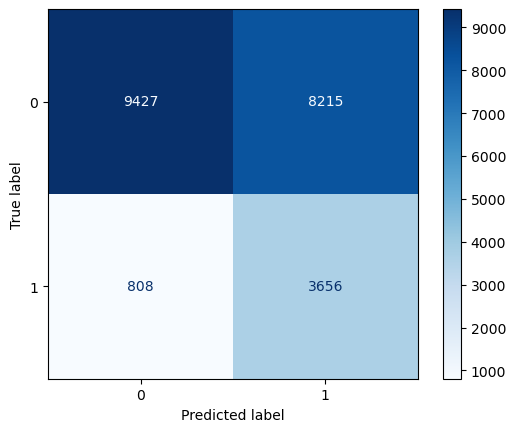

In [6]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_train,
)

threshold_model = baseline_model.fit(X_subtrain, y_subtrain)
valid_score = threshold_model.predict_proba(X_valid)[:, 1]
threshold_candidates = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
threshold_summary = classification_thresholds_frame(y_valid, valid_score, threshold_candidates)
operating_threshold = threshold_summary.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]["threshold"]

print_section("Threshold Tuning")
print(f"Selected operating threshold: {operating_threshold:.2f}")
display(threshold_summary)

final_model = baseline_model.fit(X_train, y_train)
y_score = final_model.predict_proba(X_test)[:, 1]
default_pred = (y_score >= 0.50).astype(int)
tuned_pred = (y_score >= operating_threshold).astype(int)

test_metrics = {
    "default_threshold_0.50": classification_report_dict(y_test, default_pred, y_score=y_score),
    f"tuned_threshold_{operating_threshold:.2f}": classification_report_dict(y_test, tuned_pred, y_score=y_score),
}
print_section("Test Metrics")
display(metrics_frame(test_metrics))
ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred, cmap="Blues")


In [7]:
MODEL_PATH = Path("models/baseline_model.joblib")
MODEL_METADATA_PATH = Path("models/baseline_model_metadata.json")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
dump(final_model, MODEL_PATH)
MODEL_METADATA_PATH.write_text(
    json.dumps(
        {
            "model_name": "logistic_regression",
            "operating_threshold": float(operating_threshold),
            "threshold_candidates": threshold_candidates,
            "test_metrics": {
                name: {metric: float(value) for metric, value in metrics.items()}
                for name, metrics in test_metrics.items()
            },
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"Saved model to: {MODEL_PATH}")
print(f"Saved metadata to: {MODEL_METADATA_PATH}")


Saved model to: models\baseline_model.joblib
Saved metadata to: models\baseline_model_metadata.json


## Error Review
- The upgraded logistic model provides useful ranking performance, and threshold tuning is the main lever for making it operationally useful rather than simply accurate at the default cutoff.
- At the default threshold, recall remains too low for outreach workflows, but a lower operating threshold captures many more likely no-shows at the cost of more false positives.
- For clinic operations, that trade-off is often acceptable because outreach capacity can be managed, while missed intervention opportunities are harder to recover.

## Takeaway Summary
A junior analyst can materially improve this workflow without overengineering by keeping the model interpretable, adding simple operational features, and tuning the decision threshold. The logistic regression model remains the most practical choice because it balances explainability with useful probability scores for ranking appointments by risk. The production takeaway is that the score should guide prioritized outreach rather than act as a hard classifier at the default 0.50 threshold.